# Deteccion de Tumores (Benigno vs Maligno) con Red Neuronal

## Paso 1: Importar librerias

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.21.0
Pandas: 3.0.1
NumPy: 2.4.3


## Paso 2: Cargar y validar dataset local

In [29]:
df = pd.read_csv('Breast_cancer_Reseach.csv')

if 'diagnosis' not in df.columns:
    raise ValueError("El dataset debe contener la columna 'diagnosis' con valores B/M")

df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['target'] = df['diagnosis'].map({'B': 0, 'M': 1})

if df['target'].isna().any():
    invalidos = sorted(df.loc[df['target'].isna(), 'diagnosis'].unique())
    raise ValueError(f"Se encontraron etiquetas invalidas en diagnosis: {invalidos}")

feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

print('Dataset cargado correctamente')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Features usadas: {len(feature_cols)}")
print('Mapeo target: 0=Benigno, 1=Maligno')

df.head()

Dataset cargado correctamente
Filas: 1200
Columnas: 23
Features usadas: 21
Mapeo target: 0=Benigno, 1=Maligno


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis,target
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B,0
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B,0
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B,0
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M,1
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M,1


## Paso 3: Analisis exploratorio rapido

Valores nulos totales: 0
Benigno (0): 612
Maligno (1): 588


C:\Users\julio\AppData\Local\Temp\ipykernel_22824\3844917949.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='coolwarm')


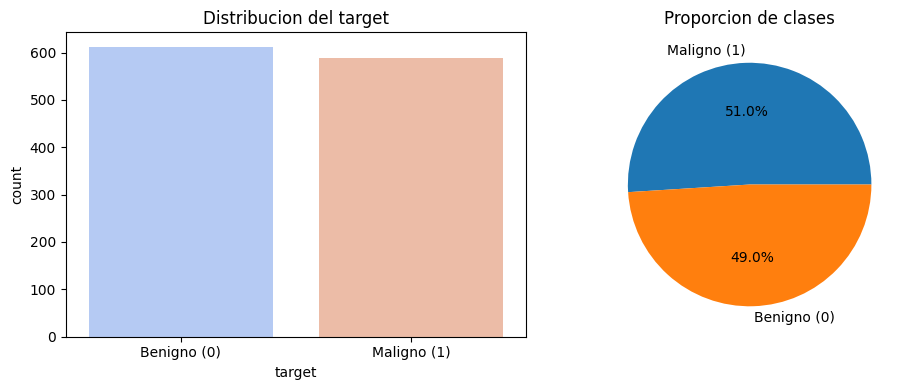

In [30]:
print('Valores nulos totales:', df.isnull().sum().sum())

conteo = df['target'].value_counts().sort_index()
print(f"Benigno (0): {conteo.get(0, 0)}")
print(f"Maligno (1): {conteo.get(1, 0)}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, palette='coolwarm')
plt.title('Distribucion del target')
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])

plt.subplot(1, 2, 2)
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Maligno (1)', 'Benigno (0)'])
plt.ylabel('')
plt.title('Proporcion de clases')

plt.tight_layout()
plt.show()

## Paso 4: Preprocesamiento (train/val/test estratificado)

In [31]:
X = df[feature_cols].copy()
y = df['target'].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

print('Escalado completado')
print(f"Media train escalado: {X_train_scaled.mean():.4f}")
print(f"Std train escalado: {X_train_scaled.std():.4f}")

Train: (768, 21), Validation: (192, 21), Test: (240, 21)
Escalado completado
Media train escalado: 0.0000
Std train escalado: 1.0000


## Paso 5: Crear y entrenar la red neuronal

In [32]:
num_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(num_features,)),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dropout(0.10),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

print('Entrenamiento finalizado')
print(f"Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4622 - loss: 0.7396 - val_accuracy: 0.4635 - val_loss: 0.7006
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4922 - loss: 0.7117 - val_accuracy: 0.4635 - val_loss: 0.7028
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5195 - loss: 0.7056 - val_accuracy: 0.4479 - val_loss: 0.7053
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5365 - loss: 0.6941 - val_accuracy: 0.4479 - val_loss: 0.7065
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5221 - loss: 0.6894 - val_accuracy: 0.4271 - val_loss: 0.7081
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5469 - loss: 0.6854 - val_accuracy: 0.4427 - val_loss: 0.7097
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5417 - loss: 0.6868 - val_accuracy: 0.4323 - val_loss: 0.7113
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5430 - loss: 0.6916 - val_accuracy: 0.4375 - 

## Paso 6: Evaluacion del modelo

In [33]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy:  0.5125
Precision: 0.5044
Recall:    0.4831
F1-score:  0.4935
ROC-AUC:   0.5348

Reporte de clasificacion:
              precision    recall  f1-score   support

 Benigno (0)       0.52      0.54      0.53       122
 Maligno (1)       0.50      0.48      0.49       118

    accuracy                           0.51       240
   macro avg       0.51      0.51      0.51       240
weighted avg       0.51      0.51      0.51       240



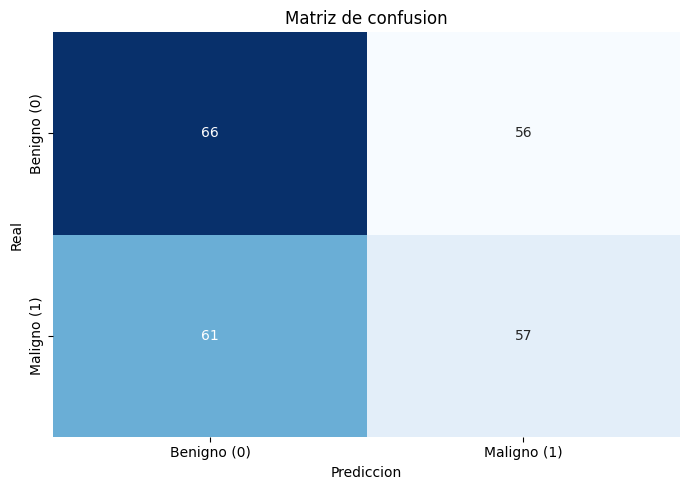

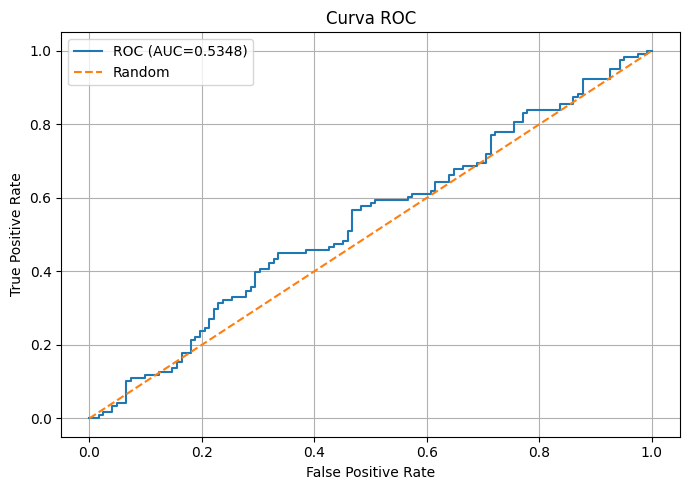

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.yticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Paso 7: Prediccion para nuevos parametros

In [35]:
TARGET_MAP = {0: 'Benigno', 1: 'Maligno'}

def predecir_tumor(parametros_entrada, modelo, escalador, columnas_modelo, umbral=0.5):
    """
    parametros_entrada: dict con las 21 features del CSV.
    """
    faltantes = [c for c in columnas_modelo if c not in parametros_entrada]
    if faltantes:
        raise ValueError(f"Faltan parametros: {faltantes}")

    x_df = pd.DataFrame([parametros_entrada], columns=columnas_modelo)
    x_scaled = escalador.transform(x_df)

    prob_maligno = float(modelo.predict(x_scaled, verbose=0).flatten()[0])
    prob_benigno = 1.0 - prob_maligno
    pred = 1 if prob_maligno >= umbral else 0

    return {
        'prob_maligno': prob_maligno,
        'prob_benigno': prob_benigno,
        'pred_clase': pred,
        'pred_etiqueta': TARGET_MAP[pred],
    }

# Ejemplo de uso
PARAMETROS_USUARIO = {
    'radius_mean': 14.12,
    'texture_mean': 19.33,
    'perimeter_mean': 91.20,
    'area_mean': 640.10,
    'smoothness_mean': 0.097,
    'compactness_mean': 0.104,
    'concavity_mean': 0.089,
    'concave_points_mean': 0.048,
    'symmetry_mean': 0.181,
    'fractal_dimension_mean': 0.062,
    'radius_se': 0.402,
    'texture_se': 1.201,
    'perimeter_se': 2.711,
    'area_se': 34.20,
    'smoothness_se': 0.0061,
    'radius_worst': 16.85,
    'texture_worst': 24.90,
    'perimeter_worst': 110.20,
    'area_worst': 830.00,
    'concavity_worst': 0.208,
    'concave_points_worst': 0.102,
}

resultado = predecir_tumor(
    PARAMETROS_USUARIO,
    modelo=model,
    escalador=scaler,
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print('=== Resultado de prediccion ===')
print(f"Prob. maligno: {resultado['prob_maligno']:.4f}")
print(f"Prob. benigno: {resultado['prob_benigno']:.4f}")
print(f"Clase predicha: {resultado['pred_clase']} -> {resultado['pred_etiqueta']}")

=== Resultado de prediccion ===
Prob. maligno: 0.5620
Prob. benigno: 0.4380
Clase predicha: 1 -> Maligno


In [36]:
# Diagnostico rapido de por que el modelo no aprende
corr_abs = df[feature_cols + ['target']].corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

print('Top 10 correlaciones absolutas con target:')
print(corr_abs.head(10))
print(f"\nCorrelacion maxima abs: {corr_abs.max():.4f}")
print(f"Correlacion media abs: {corr_abs.mean():.4f}")

print('\nDistribucion de clases en dataset completo:')
print(df['target'].value_counts(normalize=True).sort_index())

print('\nValores minimos por feature (primeras 10):')
print(df[feature_cols].min().head(10))

Top 10 correlaciones absolutas con target:
area_mean                 0.077495
concavity_worst           0.047740
radius_worst              0.043308
smoothness_mean           0.039395
area_worst                0.038161
fractal_dimension_mean    0.025154
radius_mean               0.023988
concave_points_worst      0.023732
texture_mean              0.019890
perimeter_worst           0.018607
Name: target, dtype: float64

Correlacion maxima abs: 0.0775
Correlacion media abs: 0.0215

Distribucion de clases en dataset completo:
target
0    0.51
1    0.49
Name: proportion, dtype: float64

Valores minimos por feature (primeras 10):
radius_mean                 4.276198
texture_mean                6.921951
perimeter_mean             30.177281
area_mean                 173.494428
smoothness_mean             0.042010
compactness_mean           -0.011051
concavity_mean             -0.106932
concave_points_mean        -0.009812
symmetry_mean               0.062328
fractal_dimension_mean      0.0262